In [65]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
from tqdm import tqdm

In [66]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  # h = jax.nn.elu(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

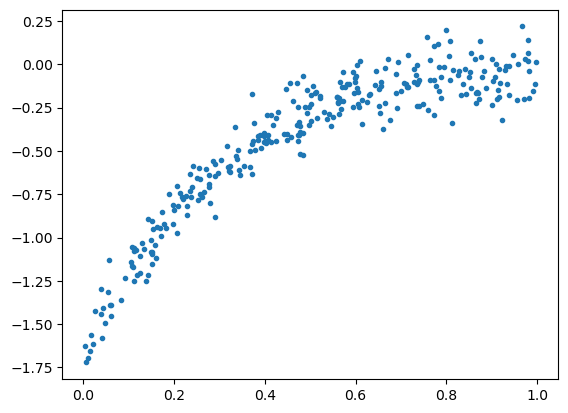

In [67]:
def target_function(z):
  params = jnp.array([2, 0.5, 3, -3])
  return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]
  # params = jnp.array([2, -0.5, 3, -3])
  # return params[2]*jnp.tanh(params[0]*z.squeeze()-params[1]) + params[3]
  # return (z.squeeze())**2
  # return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]
    Y_clean = target_function(Z)
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y = Y_clean + noise
    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z, Y = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
device = jax.devices()[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [68]:
def log_q0(x, cov=1.):
  return multivariate_normal.logpdf(x, jnp.zeros_like(x), cov)

def L(X, unravel_fn, gamma=100):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

# q0cov = 1
# log_q0_ = lambda x: log_q0(x, q0cov)
gamma = 500
L_ = jit(lambda X: L(X, unravel_fn, gamma))
S_q0 = jit(vmap(grad(log_q0)))
gradL = jit(grad(lambda X : L_(X)*len(X)))
score = lambda X: S_q0(X) - gradL(X)

In [69]:
class GradientKernel:
    def __init__(self, S_PQ, k):
        self.S_PQ = S_PQ
        self.k = jit(k)
        self.dkx = jit(jacrev(self.k, argnums=0))
        self.dky = jit(jacrev(self.k, argnums=1))
        self.d2k = jit(jacfwd(self.dky, argnums=0))
        self.K = lambda X : vmap(lambda x: vmap(lambda y: self.k(x, y))(X))(X)
        self.dKx = lambda X : vmap(lambda x: vmap(lambda y: self.dkx(x, y))(X))(X)
        self.d2K = lambda X : vmap(lambda x: vmap(lambda y: jnp.trace(self.d2k(x, y)))(X))(X)


    def evaluate(self, X):
        K = self.K(X)
        dK = self.dKx(X)
        d2K = self.d2K(X)
        S_PQ = self.S_PQ(X)
        S_dK = jnp.einsum('ijk, ijk -> ij', dK, (S_PQ[None, :, :]))
        k_pq = d2K + S_dK + S_dK.T + K * jnp.dot(S_PQ, S_PQ.T)
        return k_pq


def kgd(k_pq, X):
  return k_pq.evaluate(X).mean()

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)

def imq_scale_mixtures(x, y, scales):
  return  vmap(lambda scale: k_imq(x, y, 1, 0.5, scale))(scales).mean()

In [70]:
# @title Default title text
def gL(x, X, unravel_fn, gamma):
  Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
  # x = X[0]
  g = jax.grad(lambda x, z: forward(unravel_fn(x), z), 0)
  # print(g(x, Z[0]).shape)
  G = vmap(lambda z: g(x, z))(Z)
  # print(G.shape)
  diff= ( Y -Esp_forward )[:, None]
  result = (diff * G).mean(axis = 0)
  # print(result.shape)
  return -2*gamma * result

def stein_kernel(x, y, X, k, q0_score, unravel_fn, gamma):
  gL_ = lambda x: gL(x, X, unravel_fn, gamma)
  dkx = jit(jacrev(k, argnums=0))
  dky = jit(jacrev(k, argnums=1))
  d2k = jit(jacfwd(dky, argnums=0))
  bx = q0_score(x) - gL_(x)
  by = q0_score(y) - gL_(y)
  return bx.dot(by)* k(x, y) + dkx(x, y).dot(by) + dky(x, y).dot(bx) + jnp.trace(d2k(x, y))

def kgd_descent(kgd_fn, X0, eta, T):
  X = X0.copy()
  for step in range(T):
    g = grad(kgd_fn)(X)
    X = X - eta * g
    if step % 100 == 0:
      print(step, kgd_fn(X), L_(X))
  return X


def kgd_descent_adam(kgd_fn, X0, lr=1e-3, T=1000):
    """
    Run Adam optimization on the KGD objective wrt particles X.
    """
    tx = optax.adam(lr)
    opt_state = tx.init(X0)

    X = X0
    loss_and_grad = jax.jit(jax.value_and_grad(kgd_fn))
    particles = [X]

    losses = []
    for step in range(T):
        loss_val, g = loss_and_grad(X)
        updates, opt_state = tx.update(g, opt_state)
        X = optax.apply_updates(X, updates)
        particles.append(X)

        if step % 10 == 0:
            mse = L_(X) / gamma   # if you want MSE logging
            print(f"Step {step}, loss = {loss_val}, mse = {mse}")
            losses.append(loss_val)
          

    return particles#, jnp.array(losses)

In [71]:
import optax
T = 10000
num_particles = 50

num_stepsizes = 10
etas = jnp.logspace(-4, -1, num_stepsizes)
# num_stepsizes = 1
# etas = jnp.array([5e-3])
d = len(flat_params)
device = jax.devices()[0]

final_particles = jnp.empty((num_stepsizes, num_particles, d))

key, subkey = random.split(key)
init_std = 3
X0 = init_std*random.normal(subkey, shape=(num_particles, d))
X0 = jax.device_put(X0, device)


scale = 1e+0
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
# k = jit(lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5)))
# k = lambda x, y: x.dot(y)
# kgdd = KGDDescent(log_q0, k, unravel_fn, gamma)
k_mod = GradientKernel(score, k)
kgd_ = jit(lambda X: kgd(k_mod, X)**0.5)
# kgd_ = jit(lambda X: kgd(k_mod, X))

for e, eta in (enumerate(tqdm(etas))):
  key, subkey = random.split(key)
  #Xfinal = kgd_descent(kgd_, X0, eta, T)
  Xfinal = kgd_descent_adam(kgd_, X0, eta, T)[-1]
  final_particles = final_particles.at[e].set(Xfinal)

  0%|          | 0/10 [00:00<?, ?it/s]

Step 0, loss = 76.5896224975586, mse = 0.2122158259153366
Step 10, loss = 75.56690979003906, mse = 0.2115512639284134
Step 20, loss = 74.54895782470703, mse = 0.21089836955070496
Step 30, loss = 73.53661346435547, mse = 0.21025711297988892
Step 40, loss = 72.53014373779297, mse = 0.20962747931480408
Step 50, loss = 71.53031158447266, mse = 0.20900964736938477
Step 60, loss = 70.53742218017578, mse = 0.20840375125408173
Step 70, loss = 69.55167388916016, mse = 0.20780974626541138
Step 80, loss = 68.57352447509766, mse = 0.2072276473045349
Step 90, loss = 67.60324096679688, mse = 0.2066574990749359
Step 100, loss = 66.64108276367188, mse = 0.20609910786151886
Step 110, loss = 65.68754577636719, mse = 0.20555244386196136
Step 120, loss = 64.74280548095703, mse = 0.20501741766929626
Step 130, loss = 63.80723190307617, mse = 0.20449380576610565
Step 140, loss = 62.88128662109375, mse = 0.20398159325122833
Step 150, loss = 61.96531295776367, mse = 0.20348049700260162
Step 160, loss = 61.0596

 10%|█         | 1/10 [00:06<00:59,  6.62s/it]

Step 9950, loss = 11.712945938110352, mse = 0.07521644234657288
Step 9960, loss = 11.698062896728516, mse = 0.07511162757873535
Step 9970, loss = 11.683184623718262, mse = 0.07500667124986649
Step 9980, loss = 11.66832160949707, mse = 0.07490157335996628
Step 9990, loss = 11.653462409973145, mse = 0.07479633390903473
Step 0, loss = 76.5896224975586, mse = 0.21213844418525696
Step 10, loss = 74.39154052734375, mse = 0.2107248455286026
Step 20, loss = 72.21673583984375, mse = 0.20936663448810577
Step 30, loss = 70.06974029541016, mse = 0.2080637365579605
Step 40, loss = 67.95481872558594, mse = 0.20681601762771606
Step 50, loss = 65.87609100341797, mse = 0.20562314987182617
Step 60, loss = 63.8372917175293, mse = 0.204484224319458
Step 70, loss = 61.842308044433594, mse = 0.20339807868003845
Step 80, loss = 59.89512634277344, mse = 0.202363058924675
Step 90, loss = 57.99995422363281, mse = 0.2013774961233139
Step 100, loss = 56.16111373901367, mse = 0.2004399448633194
Step 110, loss = 54

 20%|██        | 2/10 [00:13<00:52,  6.57s/it]

...

 80%|████████  | 8/10 [00:48<00:11,  5.78s/it]

Step 0, loss = 76.5896224975586, mse = 0.19418029487133026
Step 10, loss = 29.98406410217285, mse = 0.15866997838020325
Step 20, loss = 21.735158920288086, mse = 0.1271829754114151
Step 30, loss = 17.862613677978516, mse = 0.10405570268630981
Step 40, loss = 13.82039737701416, mse = 0.08599027991294861
Step 50, loss = 11.727655410766602, mse = 0.07223467528820038
Step 60, loss = 9.745309829711914, mse = 0.06085987389087677
Step 70, loss = 8.158149719238281, mse = 0.051345277577638626
Step 80, loss = 6.884474754333496, mse = 0.04326540231704712
Step 90, loss = 5.773385524749756, mse = 0.03608228638768196
Step 100, loss = 4.764894485473633, mse = 0.029876278713345528
Step 110, loss = 4.497247695922852, mse = 0.02574111707508564
Step 120, loss = 4.483031749725342, mse = 0.023251105099916458
Step 130, loss = 4.2899909019470215, mse = 0.02156471461057663
Step 140, loss = 3.8142871856689453, mse = 0.020335447043180466
Step 150, loss = 3.756669759750366, mse = 0.01940709911286831
Step 160, lo

 90%|█████████ | 9/10 [00:54<00:05,  5.85s/it]

Step 9970, loss = 1.5075827836990356, mse = 0.011449050158262253
Step 9980, loss = 1.507322072982788, mse = 0.011449160985648632
Step 9990, loss = 1.507401466369629, mse = 0.011449090205132961
Step 0, loss = 76.5896224975586, mse = 0.2057272344827652
Step 10, loss = 23.019447326660156, mse = 0.13041841983795166
Step 20, loss = 15.539326667785645, mse = 0.09050847589969635
Step 30, loss = 11.225327491760254, mse = 0.06541219353675842
Step 40, loss = 8.902542114257812, mse = 0.04890340194106102
Step 50, loss = 6.167837619781494, mse = 0.03755629435181618
Step 60, loss = 5.130422592163086, mse = 0.029685892164707184
Step 70, loss = 5.033712387084961, mse = 0.025245120748877525
Step 80, loss = 4.933011054992676, mse = 0.022773636505007744
Step 90, loss = 4.833840370178223, mse = 0.02131159044802189
Step 100, loss = 4.435067653656006, mse = 0.020260591059923172
Step 110, loss = 4.195821285247803, mse = 0.019421834498643875
Step 120, loss = 4.051529884338379, mse = 0.018752185627818108
Step 

100%|██████████| 10/10 [01:00<00:00,  6.09s/it]


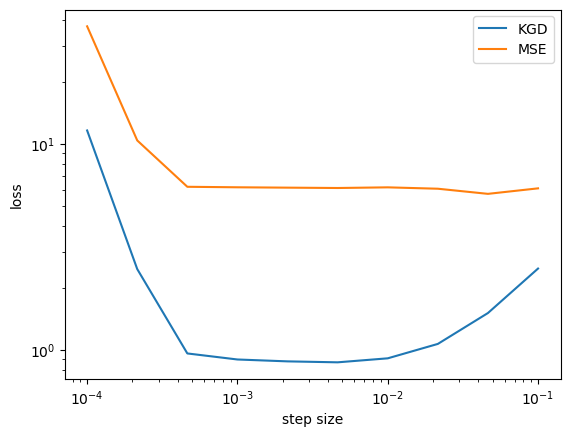

In [72]:
# Evaluate KGDs for obtained particles
scale = 1
# k = jit(lambda x, y: k_imq(x/scale, y/scale, 1, 0.5) + x.dot(y))
# k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
k = jit( lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5)))
# k = lambda x, y: x.dot(y)
# k_pq = GradientKernel(score, k)
# kgds = [kgdd.kgd(final_particles[e]) for e in range(num_stepsizes)]
kgds = [kgd_(final_particles[e]) for e in range(num_stepsizes)]
kgds = jnp.array(kgds)
mses = jnp.array( [L_(final_particles[e]) for e in range(num_stepsizes)])
plt.xlabel('step size')
plt.ylabel('loss')
plt.yscale('log')
plt.xscale('log')
plt.plot(etas, kgds, label='KGD')
plt.plot(etas, mses, label='MSE')
plt.legend()
plt.show()
# median_kgd = jnp.median(kgds, axis=0)
# kgd_ci_low = jnp.quantile(kgds, ql, axis=0)
# kgd_ci_high = jnp.quantile(kgds, qr, axis=0)

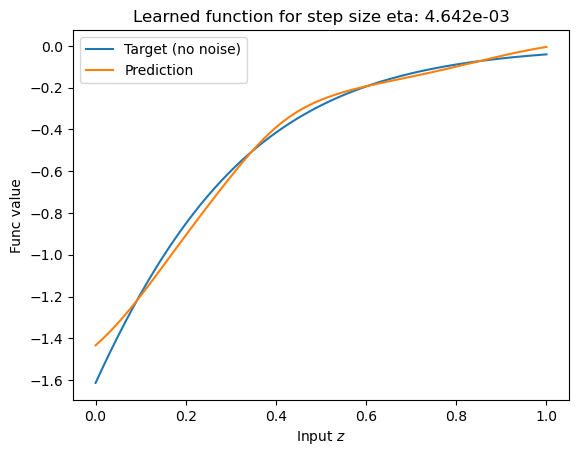

In [73]:
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
i_eta = jnp.argmin(kgds) # step size's index
# predictions =  (lambda i: vmap(lambda z: forward_(final_particles[i_eta], z, unravel_fn))(Ztest))(jnp.arange(n_sim))
predictions =  vmap(lambda z: forward_(final_particles[i_eta], z, unravel_fn))(Ztest)

plt.plot(Ztest, target_values, label='Target (no noise)')
plt.plot(Ztest, predictions, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [74]:
gradL(final_particles[i_eta])

Array([[-1.53110132e-01, -2.28518024e-01,  1.59626633e-01,
         3.42355490e-01],
       [ 2.78200895e-01,  1.85612828e-01, -1.79031789e-01,
         3.42355490e-01],
       [ 1.21931478e-01,  7.04684528e-03, -5.60972214e-01,
         3.42355490e-01],
       [ 3.11305523e-02,  3.72407794e-01,  1.83282018e-01,
         3.42355490e-01],
       [ 1.41037554e-01,  2.33481914e-01, -1.46015435e-01,
         3.42355490e-01],
       [ 1.59044123e+00,  5.16851711e+00,  1.38796329e-01,
         3.42355490e-01],
       [-2.74577066e-02, -1.43139079e-01,  4.23098624e-01,
         3.42355490e-01],
       [-4.14541543e-01, -3.31032544e-01,  8.52187872e-02,
         3.42355490e-01],
       [-2.90749359e+00, -7.01955748e+00,  1.21244240e+00,
         3.42355490e-01],
       [-2.24715257e+00, -3.10918546e+00,  9.44344759e-01,
         3.42355490e-01],
       [-3.11902136e-01, -5.36025576e-02,  2.18352485e+00,
         3.42355490e-01],
       [-1.73242420e-01,  3.35089028e-01, -1.86248720e-02,
      

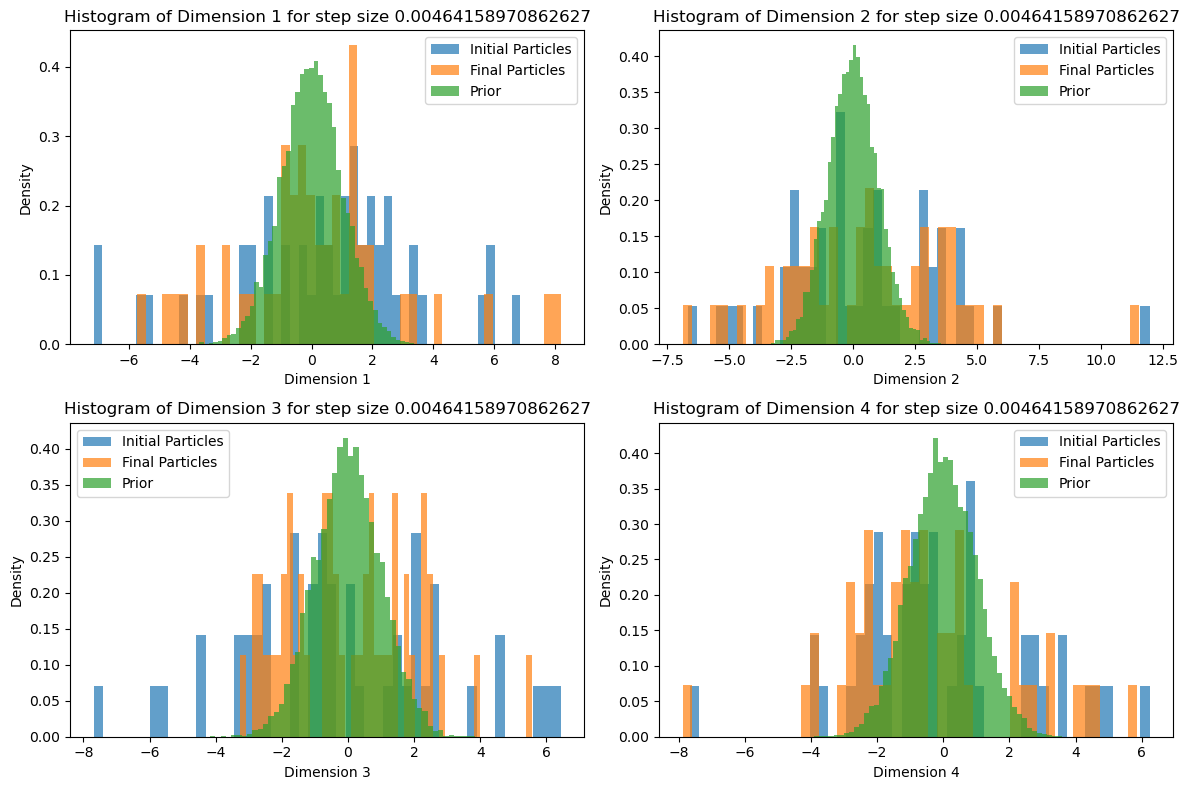

In [75]:
plt.figure(figsize=(12, 8))
prior_mass = random.normal(key, shape=(10000, d))

for i in range(d):
    plt.subplot(2, 2, i + 1)
    plt.hist(X0[:, i], bins=50, density=True, alpha=0.7, label='Initial Particles')
    plt.hist(final_particles[i_eta, :, i], bins=50, density=True, alpha=0.7, label='Final Particles')
    plt.hist(prior_mass[:, i], bins=50, density=True, alpha=0.7, label='Prior')
    plt.xlabel(f'Dimension {i + 1}')
    plt.ylabel('Density')
    plt.title(f'Histogram of Dimension {i + 1} for step size {etas[i_eta]}')
    plt.legend()

plt.tight_layout()
plt.show()

In [76]:
def mmd(k, X, Y):
  Kxx = vmap( lambda x: vmap( lambda y: k(x, y))(X))(X)
  Kyy = vmap( lambda x: vmap( lambda y: k(x, y))(Y))(Y)
  Kxy = vmap( lambda x: vmap( lambda y: k(x, y))(Y))(X)
  return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

mmd( lambda x, y: k_imq(x, y, 1, 0.5, 10), X0, final_particles[i_eta])

Array(0.00570846, dtype=float32)

In [77]:
eta = etas[i_eta]
particles_opt = kgd_descent_adam(kgd_, X0, eta, T)
F = particles_opt[-1]

Step 0, loss = 76.5896224975586, mse = 0.20929600298404694
Step 10, loss = 38.77547073364258, mse = 0.19323092699050903
Step 20, loss = 38.058570861816406, mse = 0.19087621569633484
Step 30, loss = 33.86600875854492, mse = 0.18362024426460266
Step 40, loss = 33.00240707397461, mse = 0.17795853316783905
Step 50, loss = 31.25627326965332, mse = 0.1729697287082672
Step 60, loss = 30.00933265686035, mse = 0.16760309040546417
Step 70, loss = 28.808168411254883, mse = 0.1623561978340149
Step 80, loss = 27.624774932861328, mse = 0.15747490525245667
Step 90, loss = 26.501846313476562, mse = 0.15261510014533997
Step 100, loss = 25.43445587158203, mse = 0.14800316095352173
Step 110, loss = 24.418928146362305, mse = 0.143550306558609
Step 120, loss = 23.455541610717773, mse = 0.1392667293548584
Step 130, loss = 22.54401206970215, mse = 0.13514748215675354
Step 140, loss = 21.684064865112305, mse = 0.13117164373397827
Step 150, loss = 20.875030517578125, mse = 0.12733182311058044
Step 160, loss = 

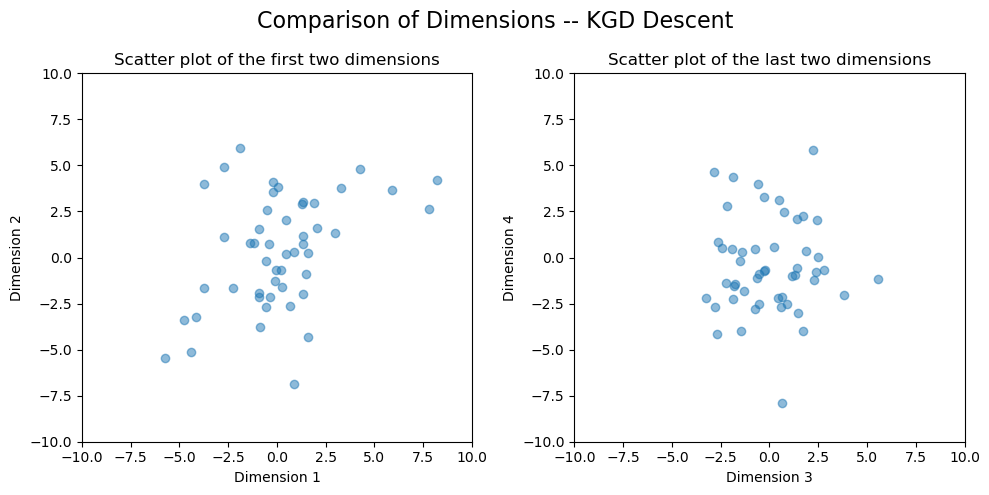

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First scatter plot
axes[0].scatter(F[:, 0], F[:, 1], alpha=0.5)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_xscale('linear')
axes[0].set_yscale('linear')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Scatter plot of the first two dimensions')

# Second scatter plot
axes[1].scatter(F[:, 2], F[:, 3], alpha=0.5)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_xscale('linear')
axes[1].set_yscale('linear')
axes[1].set_xlabel('Dimension 3')
axes[1].set_ylabel('Dimension 4')
axes[1].set_title('Scatter plot of the last two dimensions')
fig.suptitle("Comparison of Dimensions -- KGD Descent", fontsize=16)
plt.tight_layout()
plt.show()

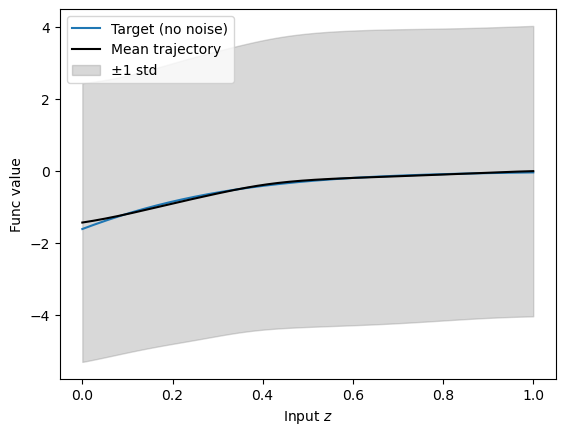

In [79]:
N = len(F)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
predictions = vmap(lambda i: vmap(lambda z: forward_(F[None, i, :], z, unravel_fn))(Ztest))(jnp.arange(N))

mean = predictions.mean(axis=0)
std = predictions.std(axis=0)
plt.plot(Ztest.squeeze(), target_values, label='Target (no noise)')
plt.plot(Ztest.squeeze(), mean, color="k", label="Mean trajectory")
plt.fill_between(Ztest.squeeze(), mean - std, mean + std,
                 color="gray", alpha=0.3, label="±1 std")
# plt.heatmap(predictions, cmap="viridis", cbar=True)

# plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

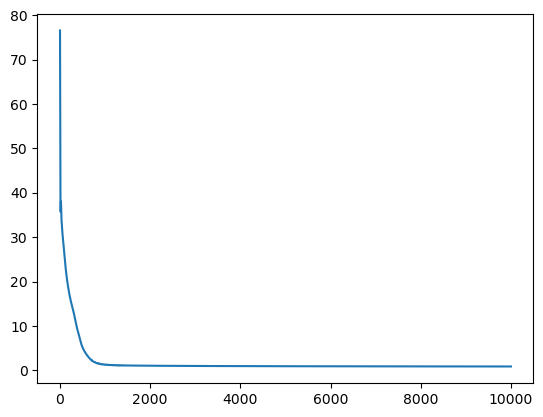

In [80]:
KGD_values = []
for it in range(T):
    KGD_values.append(kgd_(particles_opt[it]))
plt.plot( KGD_values)

In [81]:
final_particles.shape

(10, 50, 4)

In [82]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro = pickle.load(g)

In [85]:
results_heishiro["KGD Descent"]["X_fin"] = F
results_heishiro["KGD Descent"]["KGD_values"] = KGD_values

In [86]:
import pickle

with open("results_heishiro.pkl", "wb") as g:
    pickle.dump(results_heishiro, g)